# Comparación de Modelos — ECG Multi-Label Classification
## Carga resultados pre-computados de los notebooks individuales.
## NO re-entrena. Requiere haber ejecutado los 3 notebooks de modelo primero.

## Celda 1 · Cargar todos los resultados

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR   = PROJECT_ROOT / "results"
METRICS_DIR   = RESULTS_DIR / "metrics"
FIGURES_DIR   = RESULTS_DIR / "figures"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12})

MODEL_NAMES = ["resnet1d", "patchtst", "cnn_transformer"]
COLORS = {"resnet1d": "#534AB7", "patchtst": "#1D9E75", "cnn_transformer": "#D85A30"}
CLASS_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]

# ── Verify all required files exist ───────────────────────────────
missing = []
for m in MODEL_NAMES:
    for fname in [f"{m}_metrics.json", f"{m}_y_true.npy",
                  f"{m}_y_pred_proba.npy", f"{m}_y_pred_binary.npy"]:
        p = METRICS_DIR / fname
        if not p.exists():
            missing.append(str(p))

if missing:
    print("ERROR: Missing files (run individual model notebooks first):")
    for f in missing:
        print(f"  {f}")
else:
    print("All required files found.")

# ── Load results ──────────────────────────────────────────────────
results = {}
for m in MODEL_NAMES:
    with open(METRICS_DIR / f"{m}_metrics.json") as f:
        results[m] = json.load(f)
    results[m]["y_true"]        = np.load(str(METRICS_DIR / f"{m}_y_true.npy"))
    results[m]["y_pred_proba"]  = np.load(str(METRICS_DIR / f"{m}_y_pred_proba.npy"))
    results[m]["y_pred_binary"] = np.load(str(METRICS_DIR / f"{m}_y_pred_binary.npy"))
    print(f"Loaded {m}: macro_auc={results[m]['macro_auc']:.4f}")


All required files found.
Loaded resnet1d: macro_auc=0.9258
Loaded patchtst: macro_auc=0.9100
Loaded cnn_transformer: macro_auc=0.9264


## Celda 2 · Tabla comparativa maestra

In [2]:
# ── Tabla comparativa maestra ─────────────────────────────────────
rows = []
for m in MODEL_NAMES:
    r = results[m]
    rows.append({
        "Model":         m,
        "Macro-AUC":     r["macro_auc"],
        "Macro-F1":      r["macro_f1"],
        "AUPRC":         r["macro_auprc"],
        "Accuracy":      r["accuracy"],
        "Sensitivity":   r["sensitivity"],
        "Specificity":   r["specificity"],
        "Params(M)":     r["n_params"] / 1e6,
        "Inference(ms)": r["inference_time_ms"],
    })

df = pd.DataFrame(rows).set_index("Model")

# Bold best value per numeric column
def highlight_best(s):
    is_best = s == s.max()
    return ["font-weight: bold" if v else "" for v in is_best]

styled = df.style.apply(highlight_best, axis=0)
display(styled.format("{:.4f}"))

df.to_csv(METRICS_DIR / "comparison_table.csv")

# LaTeX export
latex_str = df.round(4).to_latex(
    caption="Model comparison on PTB-XL+ test set.",
    label="tab:comparison",
)
with open(METRICS_DIR / "comparison_table.tex", "w") as f:
    f.write(latex_str)

print(f"Saved comparison_table.csv and comparison_table.tex → {METRICS_DIR}")
print(df.round(4).to_string())


,Macro-AUC,Macro-F1,AUPRC,Accuracy,Sensitivity,Specificity,Params(M),Inference(ms)
Model,,,,,,,,
resnet1d,0.9258,0.7409,0.8141,0.7643,0.7798,0.8988,8.9141,0.2347
patchtst,0.9100,0.7099,0.7728,0.7402,0.7458,0.8939,0.8196,0.7051
cnn_transformer,0.9264,0.7382,0.8081,0.7602,0.7959,0.8874,3.7293,0.4275


Saved comparison_table.csv and comparison_table.tex → C:\Personal\UP\ML2\ecg-classification\results\metrics
                 Macro-AUC  Macro-F1   AUPRC  Accuracy  Sensitivity  Specificity  Params(M)  Inference(ms)
Model                                                                                                     
resnet1d            0.9258    0.7409  0.8141    0.7643       0.7798       0.8988     8.9141         0.2347
patchtst            0.9100    0.7099  0.7728    0.7402       0.7458       0.8939     0.8196         0.7051
cnn_transformer     0.9264    0.7382  0.8081    0.7602       0.7959       0.8874     3.7293         0.4275


## Celda 3 · Grouped bar chart

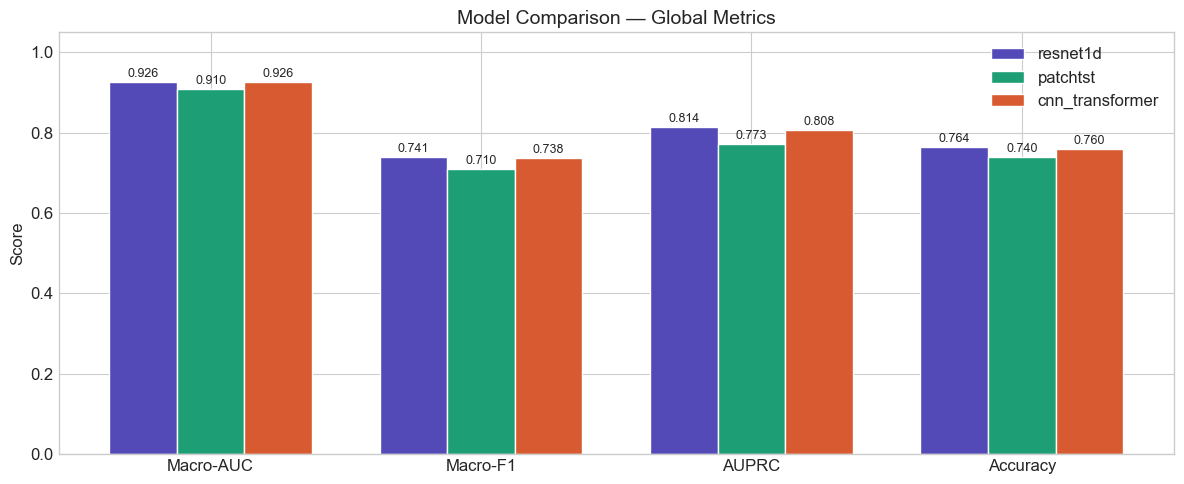

Saved grouped bar chart → C:\Personal\UP\ML2\ecg-classification\results\figures


In [3]:
# Figura — Grouped bar chart
metrics_to_plot = ["Macro-AUC", "Macro-F1", "AUPRC", "Accuracy"]
df_bar = pd.DataFrame({
    m: [results[m]["macro_auc"], results[m]["macro_f1"],
        results[m]["macro_auprc"], results[m]["accuracy"]]
    for m in MODEL_NAMES
}, index=metrics_to_plot)

x = np.arange(len(metrics_to_plot))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

for i, m in enumerate(MODEL_NAMES):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, df_bar[m], width, label=m,
                  color=COLORS[m], edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score"); ax.set_ylim([0, 1.05])
ax.set_title("Model Comparison — Global Metrics")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_metrics_bar.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "comparison_metrics_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved grouped bar chart → {FIGURES_DIR}")


## Celda 4 · ROC macro superpuestas

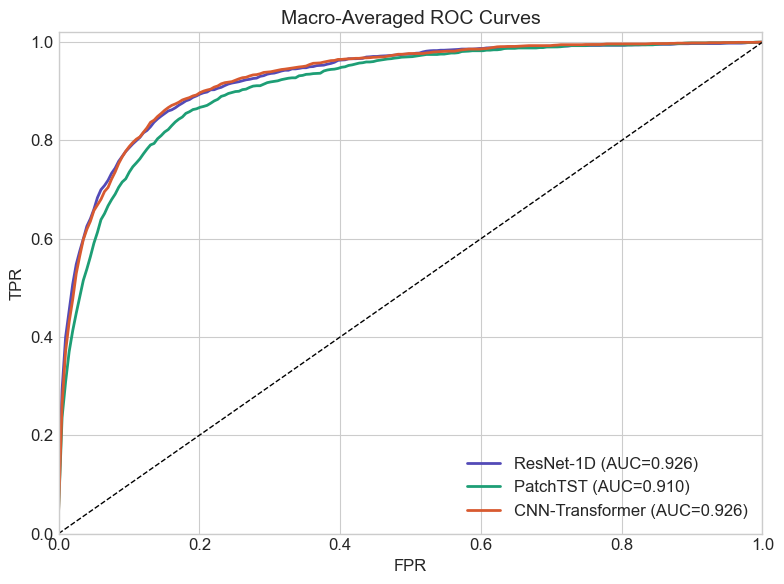

Saved macro ROC comparison → C:\Personal\UP\ML2\ecg-classification\results\figures


In [4]:
# Figura — ROC macro superpuestas
mean_fpr = np.linspace(0, 1, 200)
fig, ax  = plt.subplots(figsize=(8, 6))

for m in MODEL_NAMES:
    y_true_m = results[m]["y_true"]
    y_proba_m = results[m]["y_pred_proba"]
    mean_tpr = np.zeros_like(mean_fpr)
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_true_m[:, i], y_proba_m[:, i])
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr /= 5
    auc = results[m]["macro_auc"]
    label = {"resnet1d":"ResNet-1D","patchtst":"PatchTST","cnn_transformer":"CNN-Transformer"}[m]
    ax.plot(mean_fpr, mean_tpr, lw=2, label=f"{label} (AUC={auc:.3f})", color=COLORS[m])

ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Macro-Averaged ROC Curves")
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_roc_macro.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "comparison_roc_macro.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved macro ROC comparison → {FIGURES_DIR}")


## Celda 5 · Radar / Spider chart

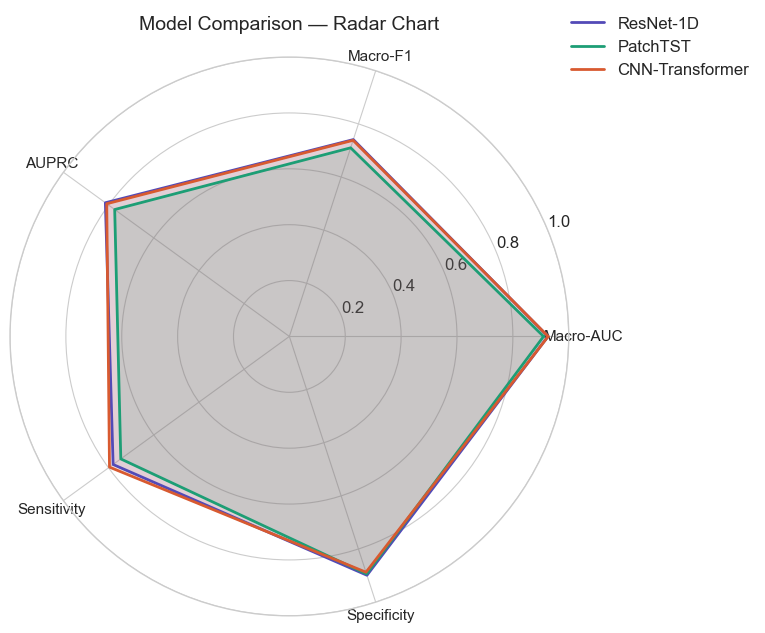

Saved radar chart → C:\Personal\UP\ML2\ecg-classification\results\figures


In [5]:
# Figura — Radar / Spider chart
categories = ["Macro-AUC", "Macro-F1", "AUPRC", "Sensitivity", "Specificity"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
label_map = {"resnet1d":"ResNet-1D","patchtst":"PatchTST","cnn_transformer":"CNN-Transformer"}

for m in MODEL_NAMES:
    r = results[m]
    values = [r["macro_auc"], r["macro_f1"], r["macro_auprc"],
              r["sensitivity"], r["specificity"]]
    values += values[:1]
    ax.plot(angles, values, lw=2, label=label_map[m], color=COLORS[m])
    ax.fill(angles, values, alpha=0.15, color=COLORS[m])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
ax.set_title("Model Comparison — Radar Chart", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_radar.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "comparison_radar.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved radar chart → {FIGURES_DIR}")


## Celda 6 · AUC por clase — heatmap

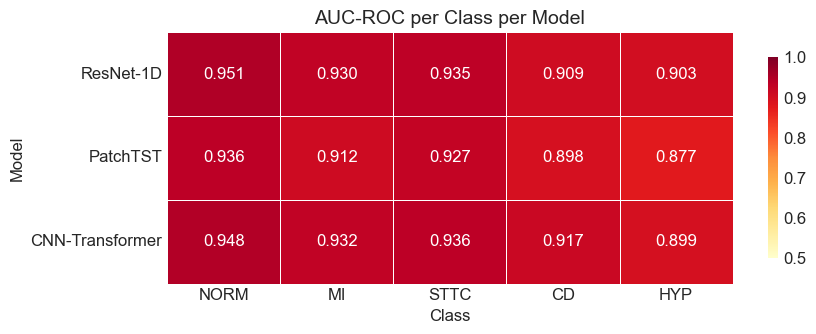

Saved AUC heatmap → C:\Personal\UP\ML2\ecg-classification\results\figures


In [6]:
# Figura — AUC por clase (heatmap 3×5)
label_map = {"resnet1d":"ResNet-1D","patchtst":"PatchTST","cnn_transformer":"CNN-Transformer"}
auc_df = pd.DataFrame(
    {m: results[m]["auc_per_class"] for m in MODEL_NAMES},
    index=CLASS_NAMES
).T
auc_df.index = [label_map[m] for m in MODEL_NAMES]

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(auc_df, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("AUC-ROC per Class per Model")
ax.set_xlabel("Class"); ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_auc_heatmap.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "comparison_auc_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved AUC heatmap → {FIGURES_DIR}")


## Celda 7 · F1 por clase — heatmap

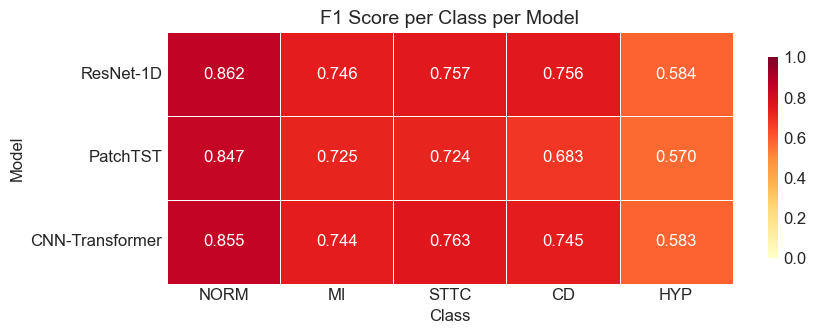

Saved F1 heatmap → C:\Personal\UP\ML2\ecg-classification\results\figures


In [7]:
# Figura — F1 por clase (heatmap 3×5)
f1_df = pd.DataFrame(
    {m: results[m]["f1_per_class"] for m in MODEL_NAMES},
    index=CLASS_NAMES
).T
f1_df.index = [label_map[m] for m in MODEL_NAMES]

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(f1_df, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0.0, vmax=1.0, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("F1 Score per Class per Model")
ax.set_xlabel("Class"); ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_f1_heatmap.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "comparison_f1_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved F1 heatmap → {FIGURES_DIR}")


## Celda 8 · Análisis estadístico (bootstrap)

In [8]:
# Análisis estadístico — Bootstrap AUC comparison
from itertools import combinations

def bootstrap_auc_diff(y_true, proba1, proba2, n_bootstrap=1000, seed=42):
    """Two-sided bootstrap test for macro AUC difference."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        a1 = roc_auc_score(y_true[idx], proba1[idx], average="macro")
        a2 = roc_auc_score(y_true[idx], proba2[idx], average="macro")
        diffs[i] = a1 - a2
    obs = roc_auc_score(y_true, proba1, average="macro") - roc_auc_score(y_true, proba2, average="macro")
    p   = float(2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)))
    return float(obs), min(p, 1.0)

print("Bootstrap AUC comparison (n_bootstrap=1000):")
print(f"{'Pair':<35} {'AUC diff':>10} {'p-value':>10}")
print("-" * 58)

# Use y_true from the first model (should be identical across models)
y_true_ref = results[MODEL_NAMES[0]]["y_true"]

for m1, m2 in combinations(MODEL_NAMES, 2):
    diff, pval = bootstrap_auc_diff(
        y_true_ref,
        results[m1]["y_pred_proba"],
        results[m2]["y_pred_proba"],
    )
    label_map2 = {"resnet1d":"ResNet","patchtst":"PatchTST","cnn_transformer":"CNN-T"}
    pair = f"{label_map2[m1]} vs {label_map2[m2]}"
    sig  = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"{pair:<35} {diff:>+10.4f} {pval:>10.4f}  {sig}")

print("\n* p<0.05  ** p<0.01  *** p<0.001  ns not significant")


Bootstrap AUC comparison (n_bootstrap=1000):
Pair                                  AUC diff    p-value
----------------------------------------------------------
ResNet vs PatchTST                     +0.0158     0.0000  ***
ResNet vs CNN-T                        -0.0006     0.7340  ns
PatchTST vs CNN-T                      -0.0163     0.0000  ***

* p<0.05  ** p<0.01  *** p<0.001  ns not significant
